In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set(style="whitegrid")

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

# Convert to a DataFrame for easier viewing/plotting
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


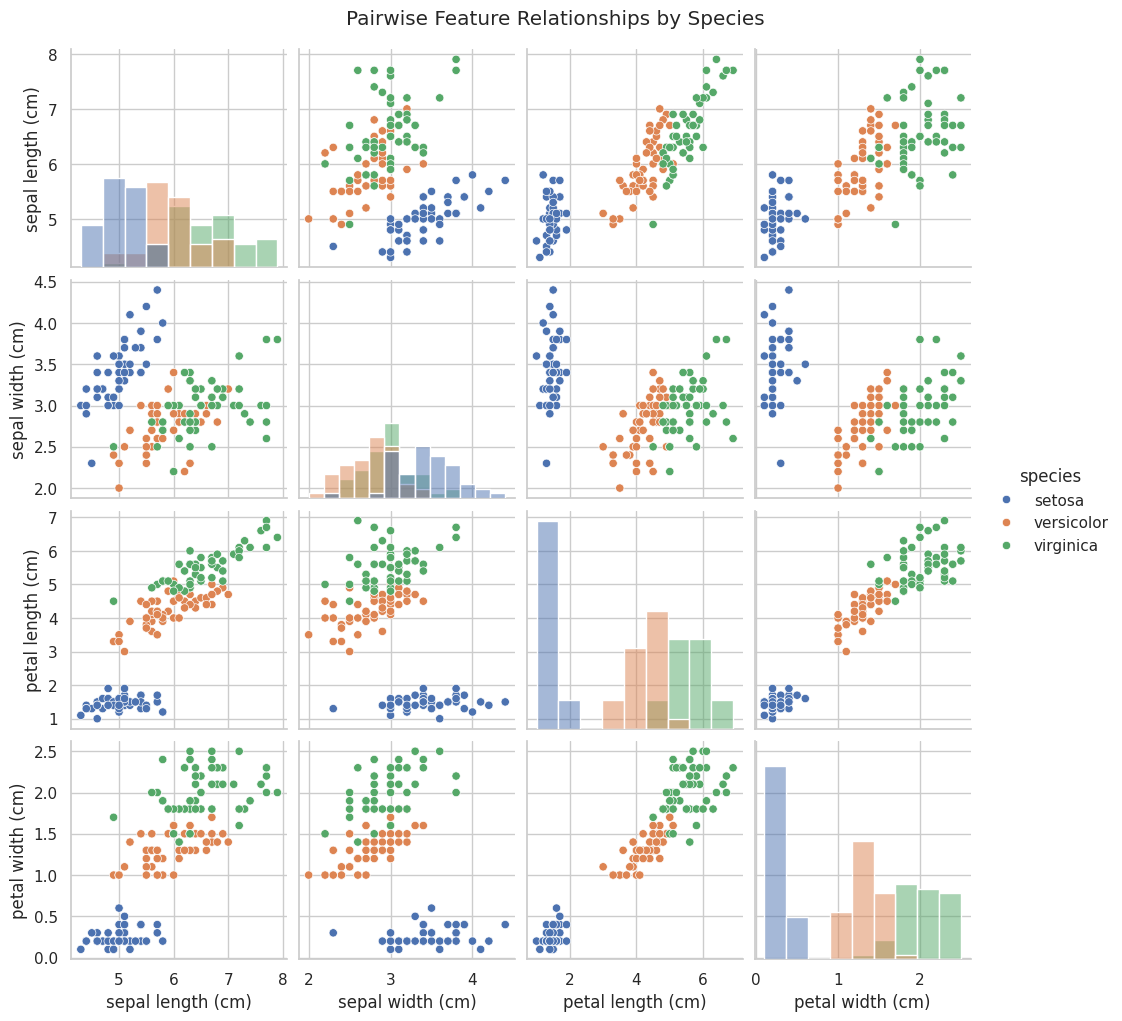

In [4]:
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()

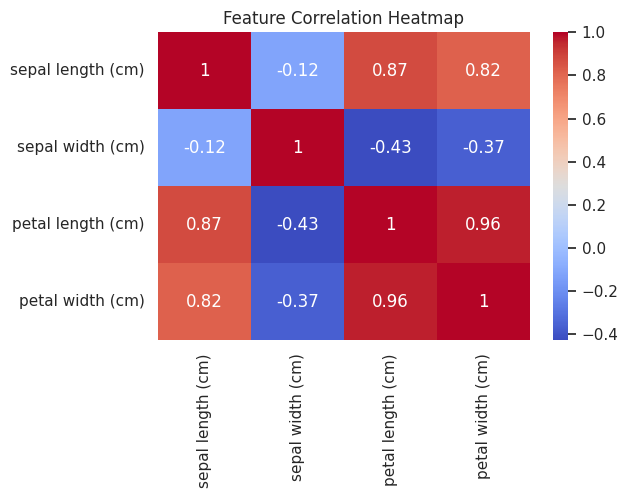

In [5]:
plt.figure(figsize=(6,4))
sns.heatmap(df.drop(columns='species').corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 120
Test size: 30


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Best k: 1, Accuracy: 0.9667


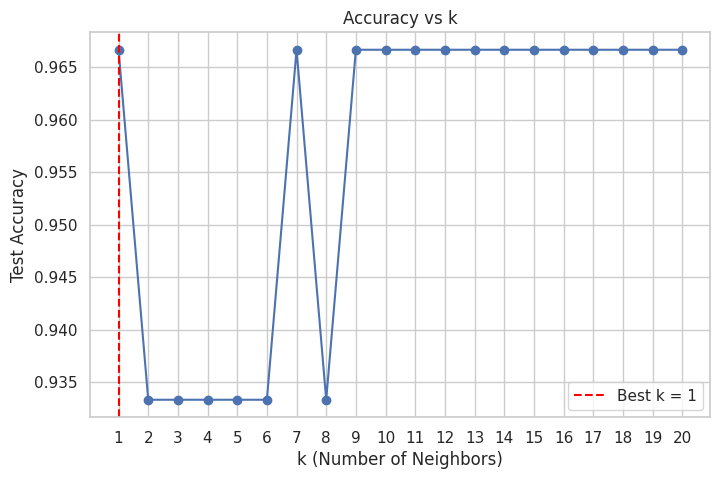

In [8]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, preds))

best_k = k_values[int(np.argmax(accuracies))]
print(f'Best k: {best_k}, Accuracy: {max(accuracies):.4f}')

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs k')
plt.xticks(k_values)
plt.legend()
plt.show()

In [9]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9666666666666667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



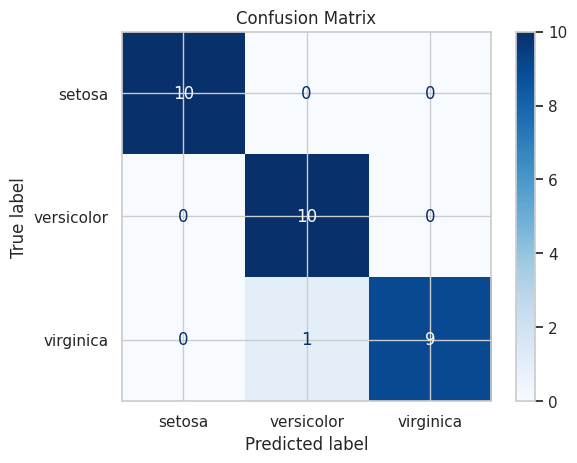

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [11]:
sample = np.array([[5.8, 3.0, 4.2, 1.3]])
sample_scaled = scaler.transform(sample)
prediction = knn.predict(sample_scaled)

print('Predicted species:', iris.target_names[prediction[0]])

Predicted species: versicolor
